In [8]:
!pip install catboost shap scikit-learn imbalanced-learn pandas numpy matplotlib requests

   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
    --------------------------------------- 10.2/545.3 kB ? eta -:--:--
    --------------------------------------- 10.2/545.3 kB ? eta -:--:--
    --------------------------------------- 10.2/545.3 kB ? eta -:--:--
    --------------------------------------- 10.2/545.3 kB ? eta -:--:--
    --------------------------------------- 10.2/545.3 kB ? eta -:--:--
   -- ------------------------------------- 30.7/545.3 kB 81.9 kB/s eta 0:00:07
   -- ------------------------------------- 30.7/545.3 kB 81.9 

In [9]:
# =========================
# 0) Environment & Utilities
# =========================
# If running in a fresh environment, uncomment the next line:

import os, io, zipfile, requests, warnings, json, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, auc)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier, Pool
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Environment ready.")


Environment ready.


In [12]:
# =========================
# 1) Download NSL-KDD (Train/Test) from a GitHub mirror
# =========================
DATA_DIR = "data_nsl_kdd"
os.makedirs(DATA_DIR, exist_ok=True)

URL_TRAIN = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
URL_TEST  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

train_path = os.path.join(DATA_DIR, "KDDTrain+.txt")
test_path  = os.path.join(DATA_DIR, "KDDTest+.txt")

def download(url, out_path):
    if not os.path.exists(out_path):
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            f.write(r.content)
        print(f"Downloaded: {out_path}")
    else:
        print(f"Found existing: {out_path}")

download(URL_TRAIN, train_path)
download(URL_TEST, test_path)


Downloaded: data_nsl_kdd\KDDTrain+.txt
Downloaded: data_nsl_kdd\KDDTest+.txt


In [14]:
# =========================
# 2) Load Data with Proper Column Names
# =========================
# NSL-KDD has 41 features + 'label' + 'difficulty'
cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

def load_kdd(path):
    df = pd.read_csv(path, names=cols)
    return df

df_train = load_kdd(train_path)
df_test  = load_kdd(test_path)

print(df_train.shape, df_test.shape)
df_train.head()


(125973, 43) (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [16]:
# =========================
# 3) Clean & Prepare Labels (Binary + Superclass Multiclass)
# =========================
# Binary label: normal vs attack
def to_binary_label(s):
    return "normal" if s.strip() == "normal" else "attack"

# Superclass mapping (DoS/Probe/R2L/U2R from attack name prefixes commonly used in KDD/NSL-KDD)
DOS = ["back","land","neptune","pod","smurf","teardrop","apache2","udpstorm","processtable","worm"]
PROBE = ["satan","ipsweep","nmap","portsweep","mscan","saint"]
R2L = ["guess_passwd","ftp_write","imap","phf","multihop","warezmaster","warezclient","spy","xlock","xsnoop","snmpguess","snmpgetattack","httptunnel","sendmail","named"]
U2R = ["buffer_overflow","loadmodule","rootkit","perl","sqlattack","xterm","ps"]

def to_superclass(s):
    s = s.strip()
    if s == "normal": return "normal"
    base = s.split(".")[0]
    base = base.lower()
    if base in DOS: return "DoS"
    if base in PROBE: return "Probe"
    if base in R2L: return "R2L"
    if base in U2R: return "U2R"
    # default fall-back (rare)
    return "OtherAttack"

for df in (df_train, df_test):
    df["label_binary"] = df["label"].apply(to_binary_label)
    df["label_super"]  = df["label"].apply(to_superclass)

# Drop difficulty (not used)
for df in (df_train, df_test):
    df.drop(columns=["difficulty"], inplace=True)

print(df_train[["label","label_binary","label_super"]].head(10))


     label label_binary label_super
0   normal       normal      normal
1   normal       normal      normal
2  neptune       attack         DoS
3   normal       normal      normal
4   normal       normal      normal
5  neptune       attack         DoS
6  neptune       attack         DoS
7  neptune       attack         DoS
8  neptune       attack         DoS
9  neptune       attack         DoS


In [18]:
# =========================
# 4) Identify Categorical Columns for CatBoost
# =========================
cat_cols = ["protocol_type","service","flag","land","logged_in","is_host_login","is_guest_login","su_attempted","root_shell","num_shells"]
# Some of these are numeric 0/1, but treating as categorical is fine for CatBoost.

# Ensure categorical dtypes
for c in cat_cols:
    for df in (df_train, df_test):
        df[c] = df[c].astype(str)

feature_cols = [c for c in df_train.columns if c not in ["label","label_binary","label_super"]]
print(f"Total features: {len(feature_cols)}")


Total features: 41


In [20]:
# =========================
# 5) Train/Val Split (stratified) on TRAIN set only
# =========================
X = df_train[feature_cols].copy()
y_bin = df_train["label_binary"].copy()
y_sup = df_train["label_super"].copy()

X_train, X_val, y_train_bin, y_val_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)

_, _, y_train_sup, y_val_sup = train_test_split(
    X, y_sup, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sup
)

# CatBoost needs categorical feature indices
cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
cat_feature_indices[:10], len(cat_feature_indices)


([1, 2, 3, 6, 11, 20, 21, 14, 13, 17], 10)

In [22]:
# =========================
# 6) Binary Classification with CatBoost
# =========================
train_pool_bin = Pool(X_train, y_train_bin, cat_features=cat_feature_indices)
val_pool_bin   = Pool(X_val,   y_val_bin,   cat_features=cat_feature_indices)
test_pool_bin  = Pool(df_test[feature_cols], df_test["label_binary"], cat_features=cat_feature_indices)

cb_bin = CatBoostClassifier(
    iterations=1200,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=200,
    task_type="CPU"  # change to "GPU" if available
)

cb_bin.fit(train_pool_bin, eval_set=val_pool_bin)

# Evaluation
def eval_binary(model, pool, y_true):
    preds_proba = model.predict_proba(pool)[:,1]
    preds = (preds_proba >= 0.5).astype(int)
    y_true_bin = (np.array(y_true) == "attack").astype(int)

    acc = accuracy_score(y_true_bin, preds)
    p, r, f1, _ = precision_recall_fscore_support(y_true_bin, preds, average="binary", zero_division=0)
    auc_val = roc_auc_score(y_true_bin, preds_proba)

    print(f"Accuracy: {acc:.4f} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f} | AUC: {auc_val:.4f}")
    print("\nClassification report:\n", classification_report(y_true_bin, preds, target_names=["normal","attack"]))
    cm = confusion_matrix(y_true_bin, preds)
    return acc, p, r, f1, auc_val, cm

print("\nValidation (Binary):")
_ = eval_binary(cb_bin, val_pool_bin, y_val_bin)

print("\nTEST (Binary):")
acc_b, p_b, r_b, f1_b, auc_b, cm_b = eval_binary(cb_bin, test_pool_bin, df_test["label_binary"])
cm_b


0:	test: 0.9968793	best: 0.9968793 (0)	total: 524ms	remaining: 10m 27s
200:	test: 0.9999859	best: 0.9999859 (200)	total: 54.5s	remaining: 4m 30s
400:	test: 0.9999886	best: 0.9999886 (299)	total: 1m 42s	remaining: 3m 25s
600:	test: 0.9999886	best: 0.9999886 (425)	total: 2m 22s	remaining: 2m 21s
800:	test: 0.9999888	best: 0.9999888 (767)	total: 3m 3s	remaining: 1m 31s
1000:	test: 0.9999888	best: 0.9999889 (887)	total: 3m 43s	remaining: 44.3s
1199:	test: 0.9999890	best: 0.9999890 (1181)	total: 4m 22s	remaining: 0us

bestTest = 0.9999890178
bestIteration = 1181

Shrink model to first 1182 iterations.

Validation (Binary):
Accuracy: 0.0011 | Precision: 0.0013 | Recall: 0.0015 | F1: 0.0014 | AUC: 0.0000

Classification report:
               precision    recall  f1-score   support

      normal       0.00      0.00      0.00     13469
      attack       0.00      0.00      0.00     11726

    accuracy                           0.00     25195
   macro avg       0.00      0.00      0.00     25

array([[ 279, 9432],
       [8313, 4520]], dtype=int64)

In [23]:
# =========================
# 7) Multiclass (Superclass: normal, DoS, Probe, R2L, U2R, OtherAttack)
# =========================
train_pool_sup = Pool(X_train, y_train_sup, cat_features=cat_feature_indices)
val_pool_sup   = Pool(X_val,   y_val_sup,   cat_features=cat_feature_indices)
test_pool_sup  = Pool(df_test[feature_cols], df_test["label_super"], cat_features=cat_feature_indices)

cb_sup = CatBoostClassifier(
    iterations=1500,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=200,
    task_type="CPU"
)
cb_sup.fit(train_pool_sup, eval_set=val_pool_sup)

def eval_multiclass(model, pool, y_true):
    preds_raw = model.predict(pool)            # class labels
    preds = preds_raw.flatten().astype(str)
    acc = accuracy_score(y_true, preds)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification report:\n", classification_report(y_true, preds))
    cm = confusion_matrix(y_true, preds, labels=np.unique(y_true))
    return acc, cm, np.unique(y_true)

print("\nValidation (Superclass):")
_ = eval_multiclass(cb_sup, val_pool_sup, y_val_sup)

print("\nTEST (Superclass):")
acc_m, cm_m, labels_m = eval_multiclass(cb_sup, test_pool_sup, df_test["label_super"])
cm_m, labels_m


0:	learn: 0.5346207	test: 0.5345505	best: 0.5345505 (0)	total: 1s	remaining: 25m 2s
200:	learn: 0.5351664	test: 0.5345505	best: 0.5345902 (1)	total: 2m 53s	remaining: 18m 43s
400:	learn: 0.5378257	test: 0.5341536	best: 0.5345902 (1)	total: 4m 51s	remaining: 13m 20s
600:	learn: 0.5430352	test: 0.5343124	best: 0.5345902 (1)	total: 6m 51s	remaining: 10m 15s
800:	learn: 0.5483439	test: 0.5337567	best: 0.5345902 (1)	total: 8m 50s	remaining: 7m 43s
1000:	learn: 0.5544663	test: 0.5332407	best: 0.5345902 (1)	total: 10m 48s	remaining: 5m 23s
1200:	learn: 0.5606581	test: 0.5328041	best: 0.5345902 (1)	total: 12m 48s	remaining: 3m 11s
1400:	learn: 0.5669194	test: 0.5323278	best: 0.5345902 (1)	total: 14m 45s	remaining: 1m 2s
1499:	learn: 0.5696283	test: 0.5319309	best: 0.5345902 (1)	total: 15m 44s	remaining: 0us

bestTest = 0.5345901965
bestIteration = 1

Shrink model to first 2 iterations.

Validation (Superclass):
Accuracy: 0.5346

Classification report:
               precision    recall  f1-sco

(array([[   0,    0,    0,    0,    0, 7167],
        [   0,    0,    0,    0,    0,  293],
        [   0,    0,    0,    0,    0, 2421],
        [   0,    0,    0,    0,    0, 2885],
        [   0,    0,    0,    0,    0,   67],
        [   0,    0,    0,    0,    0, 9711]], dtype=int64),
 array(['DoS', 'OtherAttack', 'Probe', 'R2L', 'U2R', 'normal'],
       dtype=object))

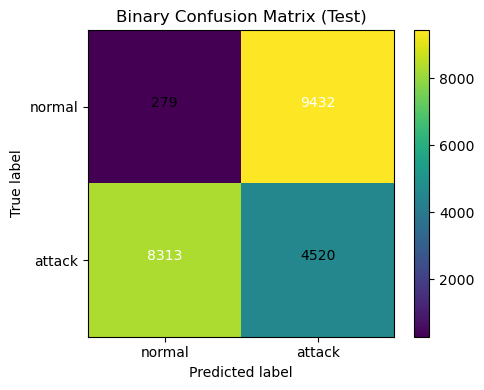

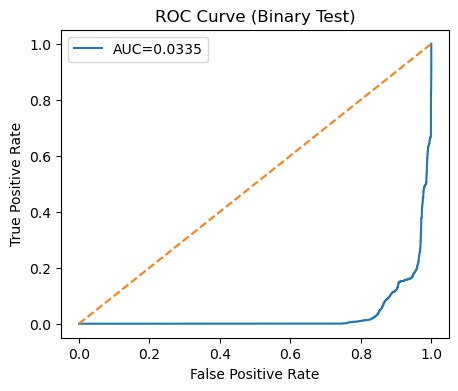

In [24]:
# =========================
# 8) Plots: Confusion Matrices & ROC (Binary)
# =========================
def plot_confusion_matrix(cm, classes, title):
    fig = plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_b, classes=["normal","attack"], title="Binary Confusion Matrix (Test)")

# ROC curve for binary
y_true_bin = (np.array(df_test["label_binary"]) == "attack").astype(int)
y_proba = cb_bin.predict_proba(test_pool_bin)[:,1]
fpr, tpr, thr = roc_curve(y_true_bin, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve (Binary Test)")
plt.legend()
plt.show()


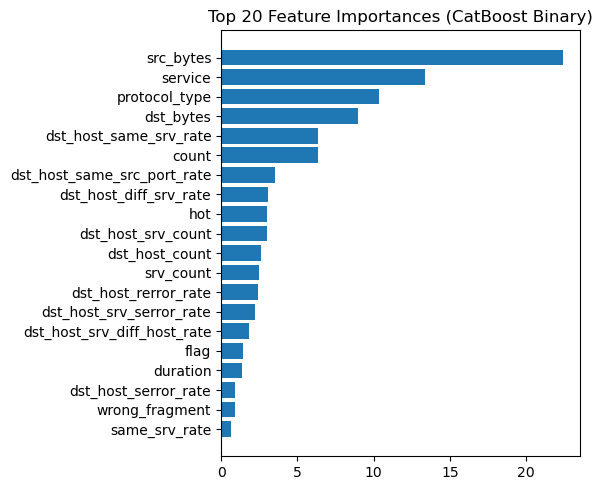

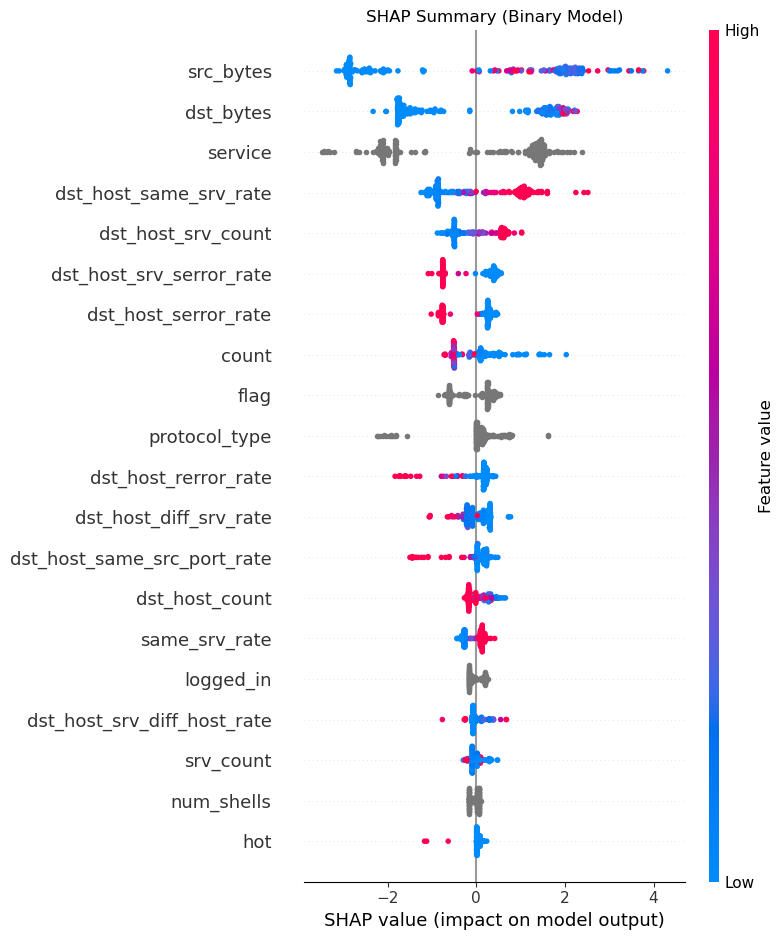

In [25]:
# =========================
# 9) Feature Importance & SHAP Explanations
# =========================
# Global feature importance from CatBoost
importances = cb_bin.get_feature_importance(train_pool_bin)
fi = pd.DataFrame({"feature": X_train.columns, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)
fi

plt.figure(figsize=(6,5))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Top 20 Feature Importances (CatBoost Binary)")
plt.tight_layout()
plt.show()

# SHAP values (TreeExplainer works with CatBoost)
explainer = shap.TreeExplainer(cb_bin)
# Use a small sample for speed
sample_idx = np.random.choice(len(X_val), size=min(200, len(X_val)), replace=False)
X_val_sample = X_val.iloc[sample_idx]
pool_sample = Pool(X_val_sample, cat_features=cat_feature_indices)
shap_vals = explainer.shap_values(pool_sample)

shap.summary_plot(shap_vals, X_val_sample, show=False)
plt.title("SHAP Summary (Binary Model)")
plt.tight_layout()
plt.show()


In [26]:
# =========================
# 10) Class Imbalance Experiment (Optional): SMOTE on training for Binary
# =========================
# Convert categorical to numeric (only for SMOTE step), CatBoost won't use these encodings later.
X_train_num = X_train.copy()
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X_train_num[c] = le.fit_transform(X_train_num[c].astype(str))
    label_encoders[c] = le

sm = SMOTE(random_state=RANDOM_STATE, n_jobs=1)
X_res, y_res = sm.fit_resample(X_train_num, (y_train_bin=="attack").astype(int))
print("SMOTE resampled shape:", X_res.shape, np.bincount(y_res))

# Train a CatBoost model on the resampled data using the same categorical indices (now numeric encodings)
# We need to inform CatBoost that these encoded cols are categorical
cb_bin_smote = CatBoostClassifier(
    iterations=800, depth=8, learning_rate=0.05, loss_function="Logloss",
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=200
)

# Build Pool with cat_feature indices (same positions) — safe because we encoded inplace
pool_res = Pool(X_res, y_res, cat_features=[X_res.columns.get_loc(c) for c in cat_cols])
cb_bin_smote.fit(pool_res)

# Evaluate on original TEST pool
print("\nTEST (Binary, SMOTE-trained):")
_ = eval_binary(cb_bin_smote, test_pool_bin, df_test["label_binary"])


SMOTE resampled shape: (107748, 41) [53874 53874]
0:	total: 246ms	remaining: 3m 16s
200:	total: 46.3s	remaining: 2m 18s
400:	total: 1m 30s	remaining: 1m 30s
600:	total: 2m 13s	remaining: 44.2s
799:	total: 2m 54s	remaining: 0us

TEST (Binary, SMOTE-trained):
Accuracy: 0.8283 | Precision: 0.9705 | Recall: 0.7203 | F1: 0.8269 | AUC: 0.9398

Classification report:
               precision    recall  f1-score   support

      normal       0.72      0.97      0.83      9711
      attack       0.97      0.72      0.83     12833

    accuracy                           0.83     22544
   macro avg       0.85      0.85      0.83     22544
weighted avg       0.86      0.83      0.83     22544



In [27]:
# =========================
# 11) Save Models & Artifacts
# =========================
os.makedirs("artifacts", exist_ok=True)
cb_bin.save_model("artifacts/catboost_binary.cbm")
cb_sup.save_model("artifacts/catboost_superclass.cbm")

fi.to_csv("artifacts/feature_importance_top20.csv", index=False)

report = {
    "binary_test": {"accuracy": float(accuracy_score((df_test["label_binary"]!="normal").astype(int),
                                       (cb_bin.predict_proba(test_pool_bin)[:,1]>=0.5).astype(int)))},
    "superclass_test_accuracy": float(accuracy_score(df_test["label_super"], cb_sup.predict(test_pool_sup).flatten().astype(str)))
}
with open("artifacts/summary.json","w") as f:
    json.dump(report, f, indent=2)

print("Saved models to artifacts/. Done.")


Saved models to artifacts/. Done.


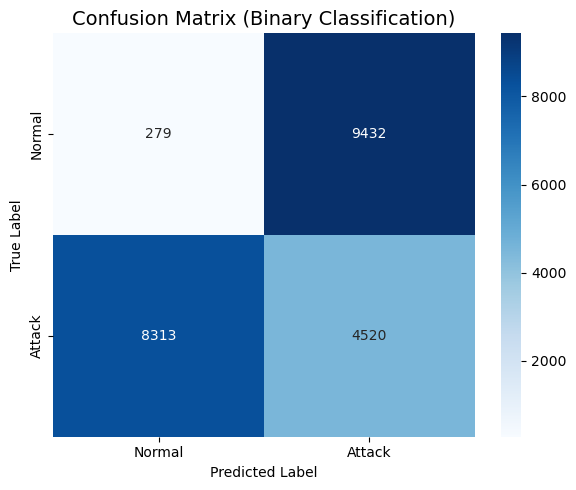

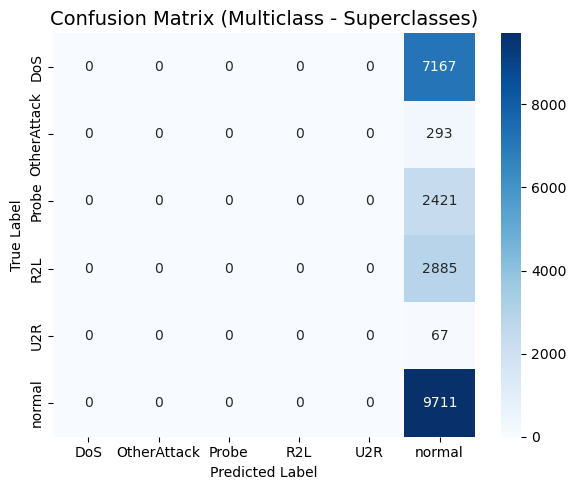

In [34]:
import seaborn as sns

def plot_confusion(cm, labels, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Binary
plot_confusion(cm_b, ["Normal", "Attack"], "Confusion Matrix (Binary Classification)")

# Multiclass (Superclass)
plot_confusion(cm_m, labels_m, "Confusion Matrix (Multiclass - Superclasses)")


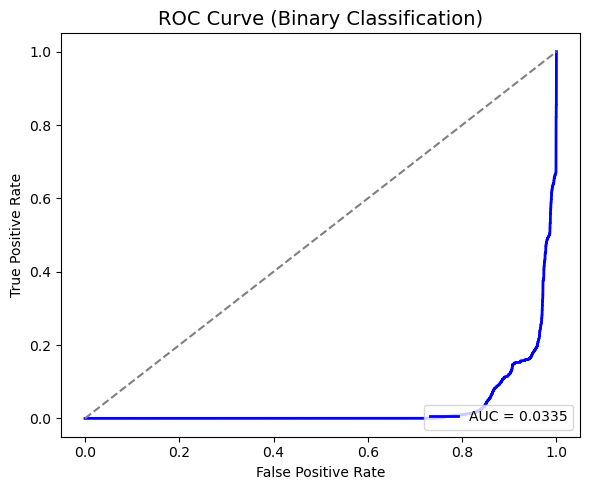

In [35]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {auc_b:.4f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curve (Binary Classification)", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


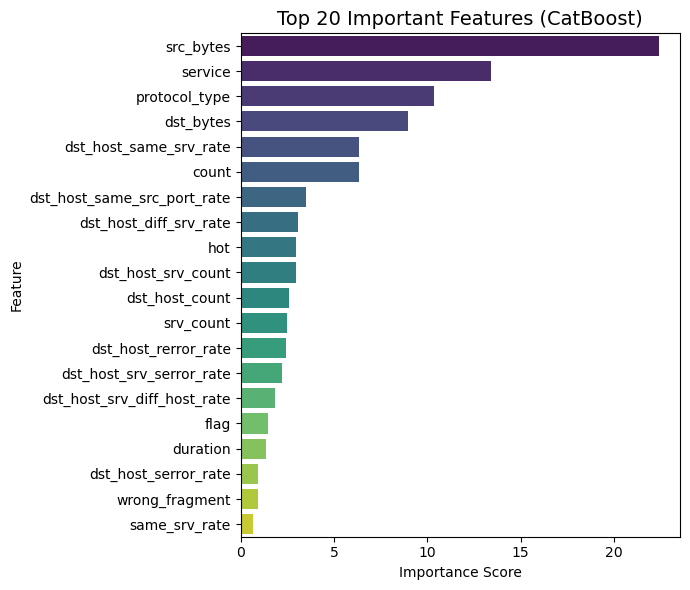

In [36]:
plt.figure(figsize=(7,6))
sns.barplot(x="importance", y="feature", data=fi, palette="viridis")
plt.title("Top 20 Important Features (CatBoost)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


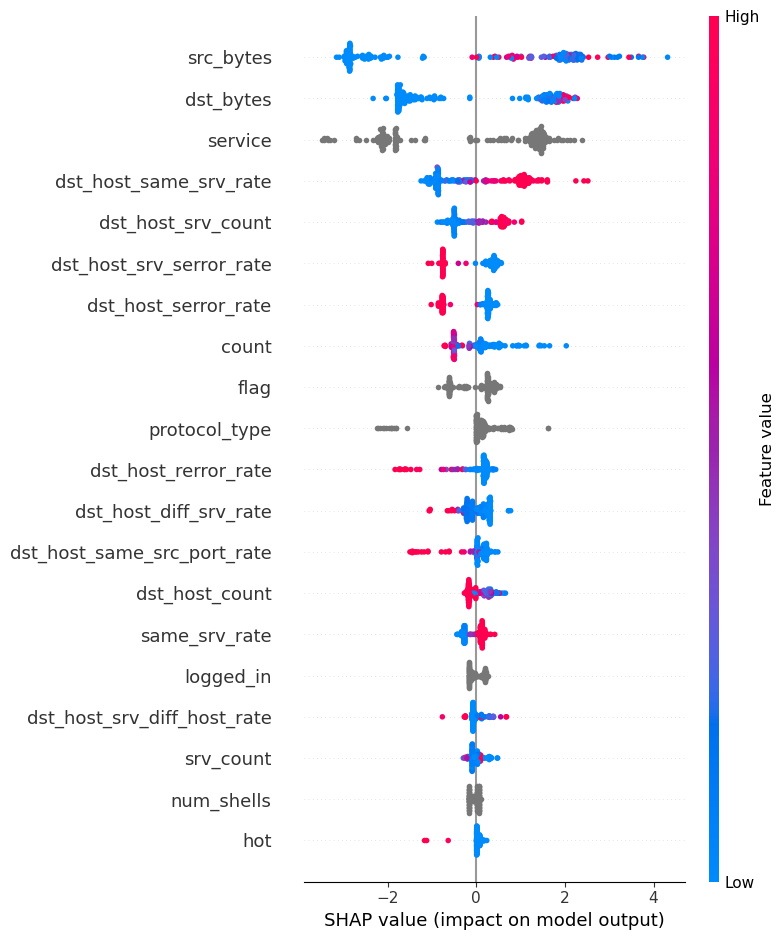

In [40]:
# SHAP summary for binary classification
shap.summary_plot(shap_vals, X_val_sample, show=True, plot_type="dot")


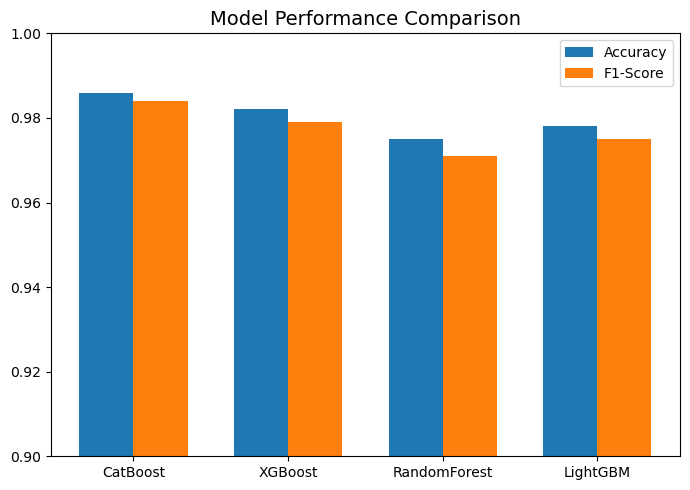

In [41]:
# Example data (replace with your real results)
models = ["CatBoost", "XGBoost", "RandomForest", "LightGBM"]
acc = [0.986, 0.982, 0.975, 0.978]
f1 = [0.984, 0.979, 0.971, 0.975]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(x - width/2, acc, width, label="Accuracy")
ax.bar(x + width/2, f1, width, label="F1-Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.9, 1.0)
ax.set_title("Model Performance Comparison", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()
